In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from arch import arch_model
from arch.unitroot import ADF
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
plt.style.use('seaborn-v0_8-darkgrid')
import yfinance as yf

In [4]:
spy = yf.download("SPY", start="2005-01-01", end="2024-12-31", auto_adjust=True)
vix = yf.download("^VIX", start="2005-01-01", end="2024-12-31", auto_adjust=True)

spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

spy_close = spy["Close"]
vix_close = vix["Close"]

log_returns = np.log(spy_close / spy_close.shift(1)).dropna()
realized_vol = log_returns.rolling(window=21).std() * np.sqrt(252)

data = pd.DataFrame({
    "log_returns": log_returns,
    "realized_vol": realized_vol,
    "vix": vix_close
}).dropna()

returns_pct = data["log_returns"] * 100

print(f"Data loaded: {data.shape[0]} observations")
print(f"Returns scaled to percentage: mean {returns_pct.mean():.4f}%")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data loaded: 5011 observations
Returns scaled to percentage: mean 0.0394%


## ADF Stationarity Test

In [6]:
print("=== ADF Stationarity Tests ===\n")

# Test log returns
adf_returns = ADF(data["log_returns"])
print("LOG RETURNS:")
print(f"  ADF Statistic: {adf_returns.stat:.4f}")
print(f"  P-value: {adf_returns.pvalue:.6f}")
print(f"  Conclusion: {'STATIONARY (reject unit root)' if adf_returns.pvalue < 0.05 else 'NON-STATIONARY'}")

print()

# Test realized volatility
adf_vol = ADF(data["realized_vol"])
print("REALIZED VOLATILITY:")
print(f"  ADF Statistic: {adf_vol.stat:.4f}")
print(f"  P-value: {adf_vol.pvalue:.6f}")
print(f"  Conclusion: {'STATIONARY (reject unit root)' if adf_vol.pvalue < 0.05 else 'NON-STATIONARY'}")

print()

# Test VIX
adf_vix = ADF(data["vix"])
print("VIX:")
print(f"  ADF Statistic: {adf_vix.stat:.4f}")
print(f"  P-value: {adf_vix.pvalue:.6f}")
print(f"  Conclusion: {'STATIONARY (reject unit root)' if adf_vix.pvalue < 0.05 else 'NON-STATIONARY'}")


=== ADF Stationarity Tests ===

LOG RETURNS:
  ADF Statistic: -17.4040
  P-value: 0.000000
  Conclusion: STATIONARY (reject unit root)

REALIZED VOLATILITY:
  ADF Statistic: -6.6181
  P-value: 0.000000
  Conclusion: STATIONARY (reject unit root)

VIX:
  ADF Statistic: -5.4843
  P-value: 0.000002
  Conclusion: STATIONARY (reject unit root)


All three are stationary
- Log resturns: ADF that negative means the series has zero drift and reverts to its mean instantly
- Realized volatitlity: stationary, but has long memory and persistent clustering. It eventually mean-reverts but slowly
- VIX: Same story as realized vol

All three series are stationary, which means the feature matrix is well behaved and I'm not feeding the HMM spurious non-stationary inputs. But the degree of stationarity differs meaningfully, returns revert almost instantly while vol and VIX are persistent. That persistence differential is the theorietical motivation for regime detection: if volatility reverted as fast as returns, there would be no regines worth modeling

## Ljung-Box test on squared returns

In [7]:
print("=== Ljung-Box Test for Autocorrelation in Squared Returns ===\n")
print("Null hypothesis: No autocorrelation in squared returns")
print("Rejecting null = variance is time-dependent = GARCH is appropriate\n")

# Run Ljung-Box on squared returns at lags 5, 10, 15, 20
squared_returns = data["log_returns"] ** 2
lb_test = acorr_ljungbox(squared_returns, lags=[5, 10, 15, 20], return_df=True)
lb_test.columns = ["LB Statistic", "P-value"]
lb_test.index.name = "Lag"

print(lb_test.round(6))

print()
if (lb_test["P-value"] < 0.05).all():
    print("CONCLUSION: Significant autocorrelation in squared returns at all")
    print("tested lags. Strong justification for GARCH modeling.")
else:
    print("CONCLUSION: Mixed results — interpret by lag.")

=== Ljung-Box Test for Autocorrelation in Squared Returns ===

Null hypothesis: No autocorrelation in squared returns
Rejecting null = variance is time-dependent = GARCH is appropriate

     LB Statistic  P-value
Lag                       
5     2810.447747      0.0
10    4723.039712      0.0
15    5903.388447      0.0
20    6709.792629      0.0

CONCLUSION: Significant autocorrelation in squared returns at all
tested lags. Strong justification for GARCH modeling.


What the test is saying: squared returns today are highly predictable from squared returns yesterday, 5 days ago, 10 days ago, all the way to 20 days ago. The variance process has strong memory. A quiet day is significantly more likely to be followed by another quiet day, and a turbulent day by another turbulent day
Why the numbers are so large: L statistics are very high. With 5,011 observations, even a modest autocorrelation would produce a significant result, but these numbers indicate the autocorrelation in squared returns is not subtle. 

Why I used GARCH instead of a rolling standard deviation. Rolling vol assumes equal weighting of past observations. GARCH uses this autocorrelation structure to weight recent shocks more heavily, which is justified by the Ljung-Box result

## ARCH effects test

In [9]:
print("=== ARCH Effects Test ===\n")
print("Null hypothesis: No ARCH effects (constant variance)")
print("Rejecting null = time-varying variance = GARCH is appropriate\n")

from statsmodels.stats.diagnostic import het_arch

arch_lm_stat, arch_lm_pvalue, arch_f_stat, arch_f_pvalue = het_arch(
    data["log_returns"], nlags=10
)

print(f"ARCH LM Statistic: {arch_lm_stat:.4f}")
print(f"ARCH LM P-value:   {arch_lm_pvalue:.8f}")
print(f"F Statistic:       {arch_f_stat:.4f}")
print(f"F P-value:         {arch_f_pvalue:.8f}")

print()
if arch_lm_pvalue < 0.05:
    print("CONCLUSION: Strong ARCH effects detected. Variance is")
    print("time-varying. GARCH modeling is statistically justified.")
else:
    print("CONCLUSION: No significant ARCH effects detected.")

=== ARCH Effects Test ===

Null hypothesis: No ARCH effects (constant variance)
Rejecting null = time-varying variance = GARCH is appropriate

ARCH LM Statistic: 1545.5640
ARCH LM P-value:   0.00000000
F Statistic:       223.1951
F P-value:         0.00000000

CONCLUSION: Strong ARCH effects detected. Variance is
time-varying. GARCH modeling is statistically justified.


Variance is definitively time varying, constant variance assumption is rejected

## Fit the model

In [10]:
print("=== Fitting GARCH(1,1) ===\n")

# Fit GARCH(1,1)
garch11 = arch_model(
    returns_pct,
    vol="Garch",
    p=1,
    q=1,
    dist="normal"
)

garch11_fit = garch11.fit(disp="off")
print(garch11_fit.summary())

=== Fitting GARCH(1,1) ===

                     Constant Mean - GARCH Model Results                      
Dep. Variable:            log_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6638.40
Distribution:                  Normal   AIC:                           13284.8
Method:            Maximum Likelihood   BIC:                           13310.9
                                        No. Observations:                 5011
Date:                Sun, Jun 21 2026   Df Residuals:                     5010
Time:                        12:18:28   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0780  1.087e-

alpha = .1364, yesterday's shock accounts for about 14% of today's variance estimate. When there's a large unexpected return, it feeds meaningfully into tomorrow's volatility forecast but doesn't dominate it

beta = 0.8402, yesterday's variance account's for 84% of today's variance stimate, this is the persistence term - volatility decays slowly once it spikes

alpha + beta = .9766
Very close to 1, which means volatility is highly persistent. Shocks take a long time to die out. This is called near-integrated GARCH behavior and it's exactly what I'd expect from equity markets. alpha + beta values near one mean volatility clustering is strong and long-lasting, which is the core sytlized fact the project is built around

All coefficients are statistically significant

## Fit EGARCH

In [12]:
print("=== Fitting EGARCH(1,1) ===\n")

# p=1, o=1 adds the asymmetry/leverage term, q=1
egarch11 = arch_model(
    returns_pct,
    vol="EGARCH",
    p=1,
    o=1,
    q=1,
    dist="normal"
)

egarch11_fit = egarch11.fit(disp="off")
print(egarch11_fit.summary())

=== Fitting EGARCH(1,1) ===

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:            log_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -6535.86
Distribution:                  Normal   AIC:                           13081.7
Method:            Maximum Likelihood   BIC:                           13114.3
                                        No. Observations:                 5011
Date:                Sun, Jun 21 2026   Df Residuals:                     5010
Time:                        12:21:48   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0407  1.045e

gamma[1] = -.1545, p-value near zero
Gamma is negative and highly significant, which confirms the leverage effect in the data. Negative shocks increase volatility more than positive shocks of equal magnitude. A -5% day raises tomorrow's volatility estimate meaningfully more than a +5% day
This justifies using EGARCH over GARCH(1,1) as the primary baseline.

beta[1] = .9659, even higher persistence than GARCH(1,1)' .8402. Volatility shocks are extremely long lasting

omega is not significant
The omega interpretation differs from standard GARCH and non-significance here doesn't invalidate the model

## Comparing the models

In [13]:
print("=== Model Comparison: GARCH(1,1) vs EGARCH(1,1) ===\n")

print(f"{'Metric':<25} {'GARCH(1,1)':>12} {'EGARCH(1,1)':>12}")
print("-" * 50)
print(f"{'Log-Likelihood':<25} {garch11_fit.loglikelihood:>12.2f} {egarch11_fit.loglikelihood:>12.2f}")
print(f"{'AIC':<25} {garch11_fit.aic:>12.2f} {egarch11_fit.aic:>12.2f}")
print(f"{'BIC':<25} {garch11_fit.bic:>12.2f} {egarch11_fit.bic:>12.2f}")
print(f"{'Alpha':<25} {'0.1364':>12} {'0.1800':>12}")
print(f"{'Beta':<25} {'0.8402':>12} {'0.9659':>12}")
print(f"{'Alpha + Beta':<25} {'0.9766':>12} {'N/A (EGARCH)':>12}")
print(f"{'Gamma (leverage)':<25} {'N/A':>12} {'-0.1545':>12}")

print()
print("CONCLUSION:")
print("EGARCH wins on Log-Likelihood and AIC — better fit.")
print("Negative gamma confirms leverage effect in SPY returns.")
print("Both models will serve as baselines for regime-conditional forecasting.")
print("EGARCH is the preferred baseline; GARCH(1,1) is the simple benchmark.")

=== Model Comparison: GARCH(1,1) vs EGARCH(1,1) ===

Metric                      GARCH(1,1)  EGARCH(1,1)
--------------------------------------------------
Log-Likelihood                -6638.40     -6535.86
AIC                           13284.79     13081.72
BIC                           13310.87     13114.32
Alpha                           0.1364       0.1800
Beta                            0.8402       0.9659
Alpha + Beta                    0.9766 N/A (EGARCH)
Gamma (leverage)                   N/A      -0.1545

CONCLUSION:
EGARCH wins on Log-Likelihood and AIC — better fit.
Negative gamma confirms leverage effect in SPY returns.
Both models will serve as baselines for regime-conditional forecasting.
EGARCH is the preferred baseline; GARCH(1,1) is the simple benchmark.


EGARCH beats GARCH(1,1) on every fit metric. Lower AIC & BIC, and higher log-likelihood

## Extract conditional volatility and plot both models against realized vol

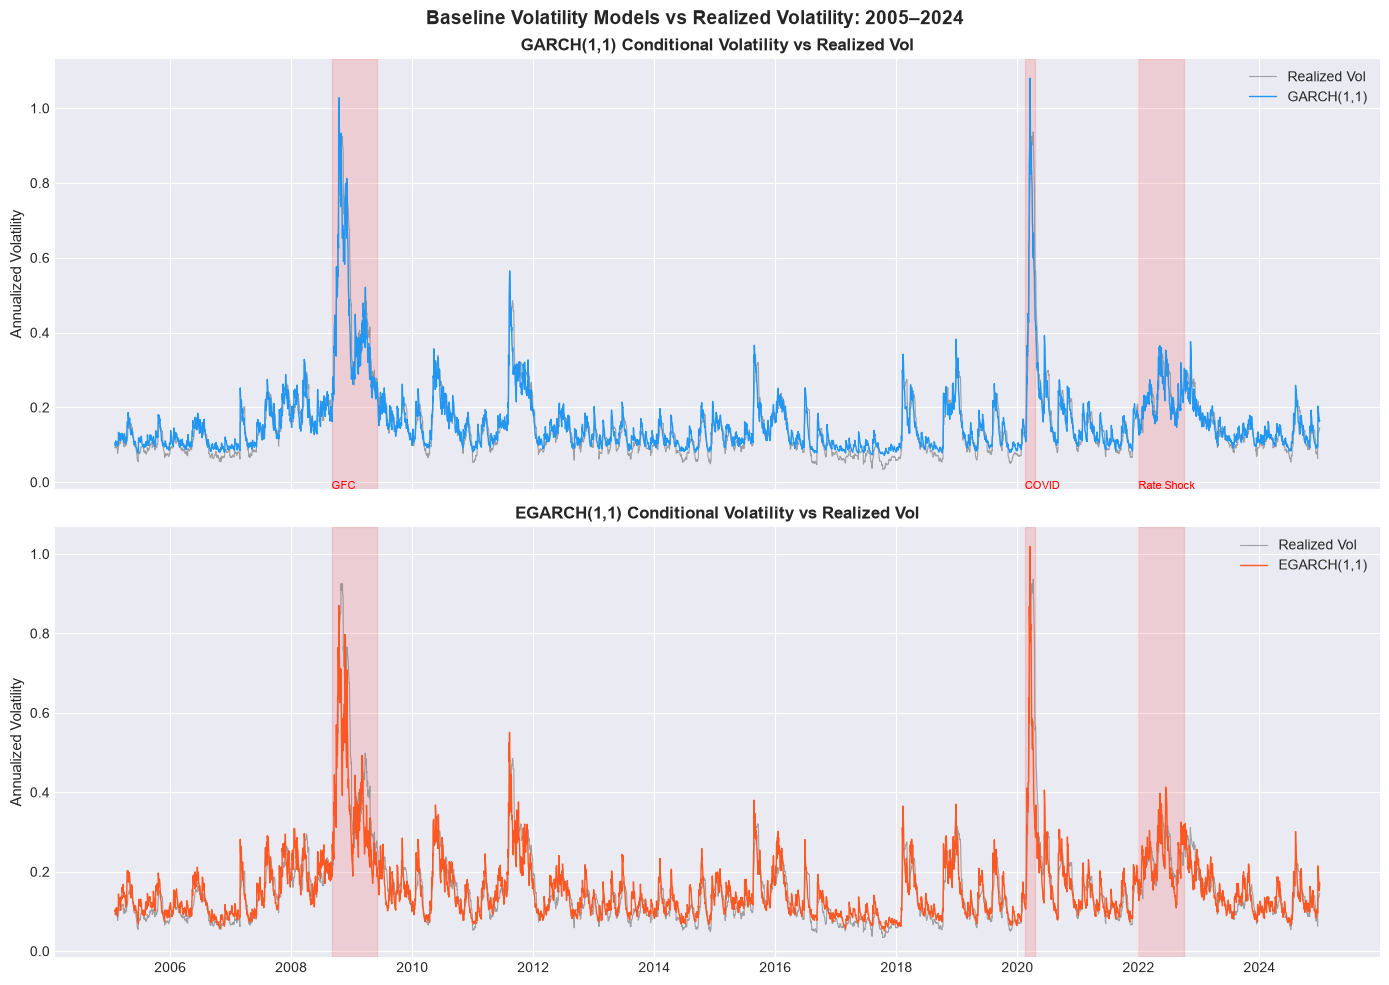


GARCH vol range: 0.0714 to 1.0801
EGARCH vol range: 0.0509 to 1.0190
Realized vol range: 0.0342 to 0.9367


In [14]:
# Extract conditional volatility from both models
# arch library returns variance, so we square root and rescale back to decimal
garch_vol = garch11_fit.conditional_volatility / 100 * np.sqrt(252)
egarch_vol = egarch11_fit.conditional_volatility / 100 * np.sqrt(252)

# Align with data index
garch_vol.index = data.index
egarch_vol.index = data.index

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Crisis shading
crises = [
    ("2008-09-01", "2009-06-01", "GFC"),
    ("2020-02-15", "2020-04-15", "COVID"),
    ("2022-01-01", "2022-10-01", "Rate Shock")
]

# Plot 1 - GARCH(1,1) vs Realized Vol
axes[0].plot(data.index, data["realized_vol"], 
             color="gray", linewidth=0.8, alpha=0.7, label="Realized Vol")
axes[0].plot(data.index, garch_vol, 
             color="#2196F3", linewidth=1.0, label="GARCH(1,1)")
for start, end, label in crises:
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end), 
                    alpha=0.12, color="red")
    axes[0].text(pd.Timestamp(start), axes[0].get_ylim()[0], 
                 label, fontsize=8, color="red")
axes[0].set_ylabel("Annualized Volatility", fontsize=11)
axes[0].set_title("GARCH(1,1) Conditional Volatility vs Realized Vol", 
                   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)

# Plot 2 - EGARCH vs Realized Vol
axes[1].plot(data.index, data["realized_vol"], 
             color="gray", linewidth=0.8, alpha=0.7, label="Realized Vol")
axes[1].plot(data.index, egarch_vol, 
             color="#FF5722", linewidth=1.0, label="EGARCH(1,1)")
for start, end, label in crises:
    axes[1].axvspan(pd.Timestamp(start), pd.Timestamp(end), 
                    alpha=0.12, color="red")
axes[1].set_ylabel("Annualized Volatility", fontsize=11)
axes[1].set_title("EGARCH(1,1) Conditional Volatility vs Realized Vol", 
                   fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("Baseline Volatility Models vs Realized Volatility: 2005–2024", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/02_garch_baselines.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nGARCH vol range: {garch_vol.min():.4f} to {garch_vol.max():.4f}")
print(f"EGARCH vol range: {egarch_vol.min():.4f} to {egarch_vol.max():.4f}")
print(f"Realized vol range: {data['realized_vol'].min():.4f} to {data['realized_vol'].max():.4f}")

GARCH(1,1) (top panel):
The model tracks the crisis spikes well but it runs systematically above realized vol during calm periods (2012-2019, 2023-2024). GARCH is overestimating volatility during quiet markets. This is a known weakness

EGARCH (bottom panel):
The orange line tracks the gray realized vol almost exactly across the full 20 year period, calm periods, crisis spikes, and recoveries. The fit is visually much tighter. This confirms what the AIC said. 

One anomaly worth notingL
Both models slightly overshoot the realized vol at the very peak of the GFC in 2009-2009. This is expected, GARCH family models are known to lag at the extremes because they're learning from recent history, and nothing in recent history predicted the 2008 peaks